# Block C, Year 1: Deep Learning Template

Name: Mohammadali Jaberi

Number: 244437

Please, use this template implement and document your solutions to the Deep Learning tasks as described in the [DataLab Tasks](https://adsai.buas.nl/Year1/BlockC/DataLabTasks.html) page. If you have any questions, please, contact your mentor or the content responsible. 

## Important Notes:
- [ ] Please, rename the file to ```Deep-Learning-YOUR_NAME-STUDENT_NUMBER.ipynb```. 
- [ ] You are allowed to add as many Markdown/Python cells as you need. 
- [ ] You are required to provide textual explanations on all tasks. Please use the markdown cells to explain all your decisions while building your image classification model.
- [ ] If more iteration steps were performed while building your model, please add more iteration sections in the template.
- [ ] If certain Markdown/Python cells were not used, please remove them from the final version of your file. 
- [ ] You must replace the instructions in the template sections with your own content.
- [ ] Your work must be reproducible, meaning that we should be able to run your code in the template and get similar results to yours. Tip: use relative paths to load your data!
- [ ] Ensure that before you hand in the template, you press ```Restart & Run all```; we should be able to see the results of your code in the notebook (i.e., output cells).
- [ ] Ensure that your code in the template is ```error-free```. In other words, we should not see any error messages when we run your code.

## Task 3.1: Create an Image Dataset

### A: Dataset Creation

**Explaination**

To make the dataset I used generative AI for some of the images. I split the data into four classes: normal, dry, oily and sensitive skin, plus one class for diseased skin. For each class I wrote 30 prompts to generate the images.

At first I got an error because the server only let me make 30 images per request. I fixed it by switching to another server, so it was not a big problem. I kept the AI generated images under 20% of the dataset and used real images for the other 80%, because I did not want the model to learn only from fake images.

For the real images I used web scraping and an image downloader. Web scraping worked but it took a lot of time and I had to filter the results by hand to get good images. The image downloader was much faster, so most of my dataset came from there.

I also added a Kaggle dataset for one class. With that I could split the data into two bigger groups, healthy skin and diseased skin, and it gave me more variety.

After collecting everything I went through the images by hand and removed the bad or unrelated ones, so the dataset is cleaner and a bit more balanced.

**Coding part**
import websocket
print("Websocket library installed correctly.")

import uuid
import json
import urllib
import random
import io
import os
import websocket
from IPython.display import Image, display
import base64

comfyui_server_address = os.getenv("COMFYUI_SERVER_ADDRESS", "<COMFYUI_SERVER_ADDRESS>")
comfyui_workflow_path = "./workflow_flux_api.json"
comfyui_client_id = str(uuid.uuid4())
comfyui_username = os.getenv("COMFYUI_USERNAME", "<COMFYUI_USERNAME>")
comfyui_password = os.getenv("COMFYUI_PASSWORD", "<COMFYUI_PASSWORD>")
comfyui_credentials = base64.b64encode(f"{comfyui_username}:{comfyui_password}".encode('utf-8')).decode('utf-8')
comfyui_auth_header = f"Basic {comfyui_credentials}"

def comfyui_queue_prompt(prompt):
    p = {"prompt": prompt, "client_id": comfyui_client_id}
    data = json.dumps(p).encode('utf-8')
    req = urllib.request.Request(f"http://{comfyui_server_address}/prompt", data=data, headers = {"Authorization": comfyui_auth_header})
    return json.loads(urllib.request.urlopen(req).read())

def comfyui_get_image(filename, subfolder, folder_type):
    data = {"filename": filename, "subfolder": subfolder, "type": folder_type}
    url_values = urllib.parse.urlencode(data)
    req = urllib.request.Request(f"http://{comfyui_server_address}/view?{url_values}", headers = {"Authorization": comfyui_auth_header})
    with urllib.request.urlopen(req) as response:
        return response.read()

def comfyui_get_history(prompt_id):
    req = urllib.request.Request(f"http://{comfyui_server_address}/history/{prompt_id}", headers = {"Authorization": comfyui_auth_header})
    with urllib.request.urlopen(req) as response:
        return json.loads(response.read())

def comfyui_get_images(ws, prompt):
    prompt_id = comfyui_queue_prompt(prompt)['prompt_id']
    output_images = {}
    while True:
        out = ws.recv()
        if isinstance(out, str):
            message = json.loads(out)
            if message['type'] == 'executing':
                data = message['data']
                if data['node'] is None and data['prompt_id'] == prompt_id:
                    break 
        else:
            continue

    history = comfyui_get_history(prompt_id)[prompt_id]
    for o in history['outputs']:
        for node_id in history['outputs']:
            node_output = history['outputs'][node_id]
            if 'images' in node_output:
                images_output = []
                for image in node_output['images']:
                    image_data = comfyui_get_image(image['filename'], image['subfolder'], image['type'])
                    images_output.append(image_data)
            output_images[node_id] = images_output

    return output_images

def comfyui_generate_image_flux(prompt, seed, output_filename):
    with open(comfyui_workflow_path, "r") as file:
        workflowdata = json.load(file)

    if seed == -1:
        seed = random.randint(0, 2**32 - 1)

    # depending on the workflow used, these nodes need to be adjusted (open file workflow_flux_api.json to see all nodes)
    workflowdata["6"]["inputs"]["text"] = prompt
    workflowdata["25"]["inputs"]["noise_seed"] = seed

    ws = websocket.WebSocket()
    ws.connect("ws://{}/ws?clientId={}".format(comfyui_server_address, comfyui_client_id), header={"Authorization": comfyui_auth_header})
    images = comfyui_get_images(ws, workflowdata)

    if len(images) > 0:
        bytestream = io.BytesIO(images["9"][0])
        with open(output_filename, "wb") as outfile:
            outfile.write(bytestream.getbuffer())


import os
import json
skin_types = {
    "Normal Skin": [
        "A clear, smooth face with even-toned, hydrated skin.",
        "A person with a healthy glow and minimal visible pores.",
        "Soft, well-balanced skin with a natural radiance under natural light.",
        "A selfie of a person with normal skin and a smooth texture.",
        "A well-moisturized face with no visible oiliness or dryness.",
        "A close-up of a youthful complexion with a subtle glow.",
        "A person with refined pores and a naturally even skin tone.",
        "A fresh, natural-looking complexion with no breakouts.",
        "Evenly pigmented skin with a healthy hydration level.",
        "A normal skin type with a slight natural sheen on the cheeks.",
        "Skin that looks naturally smooth without excessive shine or dryness.",
        "A well-hydrated face that maintains a balanced complexion throughout the day.",
        "A complexion with no visible signs of irritation, redness, or oil buildup.",
        "A person with naturally soft and elastic skin under soft lighting.",
        "A face with an even skin tone and no visible blemishes.",
        "A hydrated complexion that appears plump and healthy.",
        "A close-up of healthy skin under a beauty lamp.",
        "A skin texture that remains fresh and clean throughout the day.",
        "A naturally smooth and balanced face with refined pores.",
        "A person with skin that does not require excessive skincare maintenance.",
        "A face with a fine, even texture and no visible patches of dryness or oil.",
        "A hydrated and soft skin type that does not overproduce oil.",
        "A complexion with a subtle glow without excessive shine.",
        "Skin that maintains a fresh and youthful look with minimal effort.",
        "A naturally resilient complexion with no visible stress effects.",
        "A balanced face that does not react strongly to environmental factors.",
        "A close-up of naturally healthy skin under daylight conditions.",
        "A well-maintained face with a natural glow and soft texture.",
        "A hydrated face with a refined appearance and smooth complexion.",
        "Skin that does not require heavy makeup to appear smooth and fresh."
    ],
    "Oily Skin": [
        "A person with shiny skin and visible pores, especially on the T-zone.",
        "An oily complexion reflecting light under bright conditions.",
        "A person with skin prone to excess sebum production.",
        "Skin with enlarged pores and noticeable shine.",
        "A close-up of skin with an oily surface, particularly on the forehead.",
        "A young adult with visibly oily skin in daylight.",
        "A person with skin that appears greasy after a few hours.",
        "A complexion with excess oil and occasional acne breakouts.",
        "A selfie of a person with a reflective, shiny forehead and nose.",
        "A close-up of an oily skin type with minor acne scars.",
        "A skin type that needs frequent blotting to control oiliness.",
        "A forehead that remains greasy even after washing.",
        "A complexion with congested pores and occasional breakouts.",
        "A person applying mattifying powder to reduce facial shine.",
        "A close-up of excess sebum accumulation around the nose and cheeks.",
        "A young individual struggling with oily skin and blackheads.",
        "A naturally oily face reflecting excess light under photography.",
        "A T-zone that remains greasy despite frequent cleansing.",
        "A face with persistent oil production despite using skincare treatments.",
        "A person experiencing increased shine on a humid day.",
        "A complexion that develops acne due to excess sebum.",
        "An individual using blotting paper to manage shine throughout the day.",
        "A close-up of an oily face showing a dewy but greasy look.",
        "Skin that frequently develops clogged pores due to oil buildup.",
        "A person with naturally overactive sebaceous glands.",
        "A face that appears greasy in high temperatures.",
        "A young person applying skincare products to regulate oily skin.",
        "A close-up of a nose with enlarged, oil-prone pores.",
        "A complexion prone to excessive shine but with minimal dryness.",
        "An individual dealing with shine control for an oily skin type."
    ],
    "Dry Skin": [
        "A person with flaky, rough skin due to lack of moisture.",
        "A close-up of dry skin with visible fine lines and cracks.",
        "Skin that appears dull and feels tight after cleansing.",
        "A person applying a heavy moisturizer to hydrate dry skin.",
        "A complexion with dry patches and an uneven texture.",
        "A close-up of dry lips and dehydrated skin on the cheeks.",
        "A person experiencing discomfort due to extreme skin dryness.",
        "A selfie of a person with dry skin under harsh winter conditions.",
        "A face with a matte finish and no visible oil production.",
        "Skin prone to irritation and redness due to dehydration.",
        "A complexion showing signs of tightness and discomfort.",
        "A person with skin that requires frequent moisturizing.",
        "A close-up of flaky skin that lacks hydration.",
        "A person applying a hydrating serum to dry skin.",
        "A face with visible peeling due to extreme dryness.",
        "Skin that needs extra care in cold weather.",
        "A complexion showing signs of rough texture and lack of moisture.",
        "A person experiencing tightness after using harsh cleansers.",
        "A close-up of skin with visible dehydration lines.",
        "A person with naturally dry skin applying skincare.",
        "A face that lacks natural oils, leading to dullness.",
        "A person with sensitive dry skin prone to irritation.",
        "A close-up of a parched complexion with dry spots.",
        "Skin that absorbs moisturizer quickly due to dehydration.",
        "A person with a dull and tight-looking complexion.",
        "A face that requires nourishing oils and creams.",
        "A person using an overnight mask for dry skin.",
        "A complexion with visible signs of moisture loss.",
        "A person experiencing extreme dryness in harsh climates.",
        "A close-up of dry-prone areas on the face."
    ],
    "Combination Skin": [
        "A person with an oily T-zone and dry cheeks.",
        "Skin that is both shiny in some areas and flaky in others.",
        "A face with visible pores on the forehead but dryness around the mouth.",
        "A close-up of skin with a mix of oily and dry textures.",
        "A person using different skincare products for different facial areas.",
        "A complexion that requires targeted skincare for balance.",
        "A person experiencing both acne breakouts and dry patches.",
        "Skin with some areas appearing radiant and others appearing dull.",
        "A selfie of a person dealing with combination skin challenges.",
        "A face that needs hydration in some areas and oil control in others.",
        "A person with naturally uneven skin moisture distribution.",
        "Skin that changes depending on weather conditions.",
        "A close-up of a forehead with oil buildup and dry cheeks.",
        "A person applying moisturizer to some parts of the face and toner to others.",
        "A complexion that requires a mix of skincare routines.",
        "A person with occasional acne due to mixed skin conditions.",
        "A young adult experiencing combination skin concerns.",
        "A person using two types of skincare masks for balance.",
        "A combination of shiny and matte areas on the face.",
        "A skin type that fluctuates between oily and dry phases.",
        "A face with areas of excessive oil but also some rough patches.",
        "A person with a dynamic skin type that changes over time.",
        "A close-up of mixed-texture skin needing balanced care.",
        "A person adjusting skincare products based on different facial zones.",
        "A complexion that appears hydrated but also produces excess sebum.",
        "A skincare routine tailored for managing multiple skin needs.",
        "A face where hydration and oil control must be balanced.",
        "A person using targeted treatments for different face areas.",
        "A combination of fine pores on dry areas and enlarged pores on oily zones.",
        "A complexion needing customized care to maintain balance."
    ],
    "Sensitive Skin": [
        "A person with redness and irritation due to sensitive skin.",
        "Skin prone to allergic reactions and environmental triggers.",
        "A close-up of a face with mild rosacea and visible blood vessels.",
        "A person using fragrance-free skincare to avoid irritation.",
        "Skin that reacts to harsh weather conditions with inflammation.",
        "A complexion with a weakened skin barrier and frequent discomfort.",
        "A person dealing with itchy, inflamed skin due to sensitivity.",
        "A selfie of a person avoiding strong chemicals in skincare.",
        "A face with mild eczema or dermatological sensitivity.",
        "A skin type that requires extra care and soothing ingredients.",
        "A person experiencing stinging after applying standard skincare products.",
        "A close-up of irritated skin with small red bumps.",
        "A person using gentle skincare to avoid flare-ups.",
        "A complexion that is easily triggered by external factors.",
        "A face with frequent redness, particularly on the cheeks.",
        "A person applying a calming serum for skin sensitivity.",
        "A skincare routine designed for fragile, reactive skin.",
        "A person avoiding exfoliation due to delicate skin.",
        "A complexion showing signs of discomfort due to improper skincare.",
        "A person with extra-sensitive skin prone to inflammation.",
        "A close-up of a face showing visible irritation after sun exposure.",
        "A person choosing hypoallergenic products for skin protection.",
        "A sensitive complexion prone to redness and dryness.",
        "A person using soothing masks to alleviate skin discomfort.",
        "A skin type that reacts strongly to pollution and environmental stressors.",
        "A person avoiding makeup due to hypersensitive skin.",
        "A complexion needing gentle, non-irritating care.",
        "A face showing mild swelling due to a sensitive reaction.",
        "A person applying a dermatologist-recommended soothing cream.",
        "A complexion that turns red easily with minor skin contact."
    ]
}

# number of images to generate per class
num_images_per_class = 30

# additional prompt to ensure that only realistic images are generated
realistic_style_prompt = "Photography, highly detailed, sharp focus, hyperrealism." 

# create a subfolder to store the generated dataset
os.makedirs(".//dataset", exist_ok=True)  
for category, prompts in skin_types.items():
     # create a subfolder for the category
     os.makedirs(".//dataset//" + category, exist_ok=True) 

     for i in range(num_images_per_class):  
          # pick a random prompt from the list of prompts
          random_prompt = prompts[random.randint(0, len(prompts) - 1)] 

          # generate and save the image
          image_filename = ".//dataset//" + category + "//" + category + "_" + str(i + 1) + ".png"
          comfyui_generate_image_flux(random_prompt + " " + realistic_style_prompt, -1, image_filename)
          print("Generated image: " + image_filename)




# -*- coding: utf-8 -*-
 **This code is for Image Downloader ** 


 
from __future__ import print_function
import sys
from mainwindow import MainWindow
from PyQt5.Qt import QApplication


def main():
    app = QApplication(sys.argv)

    font = app.font()
    if sys.platform.startswith("win"):
        font.setFamily("Microsoft YaHei")
    else:
        font.setFamily("Ubuntu")
    app.setFont(font)

    main_window = MainWindow()
    main_window.setWindowTitle("Image Downloader")
    main_window.show()

    sys.exit(app.exec_())


if __name__ == '__main__':
    main()


### B: Dataset Cleaning

In this part (Dataset Cleaning) I first converted all the images to JPG, because the Datalab task asked for one format and I wanted everything to be consistent. After that I removed the blurry images. I did this because blurry images can confuse the model and hurt the validation accuracy.

Once the blurry ones were gone I made a new folder and copied only the sharp images into it, so I ended up with a clean dataset of clear JPG images.

Then I checked that all images were in RGB, because mixed color channels can also cause problems for the model.

Finally I wrote a small script to count the images per class. I have four classes and I wanted to check the classes were not too unbalanced. The counts were close enough, so I did not need to fix anything.

In [ ]:
import os

# Root folder that holds the image dataset.
# Set the DATA_DIR environment variable to point at your dataset,
# otherwise it defaults to a local "data" folder next to this notebook.
DATA_DIR = os.getenv("DATA_DIR", "data")


In [2]:
import os
import cv2

def convert_images_to_format(input_dir, output_dir, target_format="jpg"):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for class_name in os.listdir(input_dir):  # Loop through class folders
        class_path = os.path.join(input_dir, class_name)
        output_class_path = os.path.join(output_dir, class_name)

        if os.path.isdir(class_path):
            if not os.path.exists(output_class_path):
                os.makedirs(output_class_path)

            for img_name in os.listdir(class_path):
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path)

                if img is not None:
                    new_img_name = os.path.splitext(img_name)[0] + f".{target_format}"
                    new_img_path = os.path.join(output_class_path, new_img_name)
                    cv2.imwrite(new_img_path, img)  # Save image in new format

    print(f"All images converted to .{target_format}")

# Example usage
input_folder = os.path.join(DATA_DIR, "test dataset")
output_folder = os.path.join(DATA_DIR, "test dataset")
convert_images_to_format(input_folder, output_folder, target_format="jpg")  # Change to "png" if needed

All images converted to .jpg


In [3]:
import cv2
import os
import numpy as np

# Function to check if an image is blurry
def is_blurry(image_path, threshold=100):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)  # Apply Laplacian operator
    variance = laplacian.var()  # Compute variance
    
    return variance, variance < threshold  # Return variance and blur status

# Path to dataset folder
dataset_path = os.path.join(DATA_DIR, "test dataset")

# Check all images
blurry_images = []
sharp_images = []
image_variances = []

for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)
    
    if os.path.isdir(class_path):  # Ensure it's a directory
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            variance, is_blur = is_blurry(image_path, threshold=100)

            image_variances.append(variance)
            
            if is_blur:
                blurry_images.append((image_path, variance))
            else:
                sharp_images.append((image_path, variance))

# Display some results
print(f"Total Images Checked: {len(image_variances)}")
print(f"Blurry Images: {len(blurry_images)}")
print(f"Sharp Images: {len(sharp_images)}")

Total Images Checked: 2186
 Blurry Images: 108
 Sharp Images: 2078


In [4]:
import os
import shutil
shrap_dataset = os.path.join(DATA_DIR, "Sharp")
sharp_count = 0
for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)
    
    if os.path.isdir(class_path):  # Ensure it's a directory
        sharp_class_folder = os.path.join(shrap_dataset, class_folder)
        os.makedirs(sharp_class_folder, exist_ok=True)  # Create subfolder

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            variance, is_blur = is_blurry(image_path, threshold=100)

            if not is_blur:  # If the image is sharp
                dest_path = os.path.join(sharp_class_folder, image_name)
                shutil.copy(image_path, dest_path)  # Copy image
                sharp_count += 1

print(f"Sharp images saved: {sharp_count} in '{shrap_dataset}'")

Sharp images saved: 2078 in '<DATA_DIR>\Sharp'


In [5]:
import cv2
import os

# Path to the new dataset
shrap_dataset = os.path.join(DATA_DIR, "Sharp")
# Function to check if an image is RGB
def check_image_format(image_path):
    image = cv2.imread(image_path)  # OpenCV loads in BGR by default
    if image is None:
        return "Invalid Image"
    
    if len(image.shape) == 3 and image.shape[2] == 3:
        return "ok"
    elif len(image.shape) == 2:
        return "Grayscale"
    else:
        return "Unknown Format"

# Scan all images
format_results = {}
for class_folder in os.listdir(shrap_dataset):
    class_path = os.path.join(shrap_dataset, class_folder)
    
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            format_results[image_name] = check_image_format(image_path)

# Display results
for img, fmt in format_results.items():
    print(f" {fmt}")

print("Format check completed.")


 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok
 ok


In [6]:
import os
import cv2
import hashlib

def get_image_hash(image_path):
    """Generate a unique hash for an image."""
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()  # Compute MD5 hash

def remove_duplicates(folder_path):
    """Remove duplicate images in a given folder."""
    seen_hashes = {}
    deleted_count = 0

    for class_name in os.listdir(folder_path):
        class_dir = os.path.join(folder_path, class_name)
        if not os.path.isdir(class_dir):
            continue  # Skip if not a folder

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)

            if not os.path.isfile(img_path):  
                continue  # Skip non-file items

            img_hash = get_image_hash(img_path)

            if img_hash in seen_hashes:
                os.remove(img_path)  # Delete duplicate
                deleted_count += 1
                print(f"Deleted: {img_path}")
            else:
                seen_hashes[img_hash] = img_path  # Store unique image

    print(f"Finished! Deleted {deleted_count} duplicate images.")

# Set the dataset path
dataset_path =  os.path.join(DATA_DIR, "Sharp")

# Run the function
remove_duplicates(dataset_path)


Finished! Deleted 0 duplicate images.


In [7]:
import os
def count_images_per_class(dataset_path):
    """Counts the number of images in each class folder."""
    class_counts = {}

    for class_name in os.listdir(dataset_path):
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):  # Ensure it's a folder
            num_images = len([img for img in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, img))])
            class_counts[class_name] = num_images  # Store count

    return class_counts

# Set dataset path
dataset_path =  os.path.join(DATA_DIR, "Sharp")

# Get the counts
class_image_counts = count_images_per_class(dataset_path)

# Print the results
print("Number of images in each class:")
for class_name, count in class_image_counts.items():
    print(f"{class_name}: {count}")

Number of images in each class:
dry_skin: 516
normal_skin: 505
oily_skin: 512
skin diseas: 545


### C: Final Dataset

[Upload your image dataset to [BUas SharePoint](https://edubuas-my.sharepoint.com/my) and share the public link here]

https://edubuas-my.sharepoint.com/:f:/g/personal/244437_buas_nl/EuFtxsFVcwBGlJTqZIuv2MEBYuvh0p7l84DlfG8DU3JR2g?e=wv7e9O

### D: Load and Split

After counting the images I uploaded the dataset to the BUAS SharePoint. Then I wrote a script to split the data into train, validation and test sets automatically. I used 70% for training, 20% for validation and 10% for testing.

Note: do not run this code again. The script moves the images, so after the split the original Sharp folder is empty. I already ran it once, so all the images are now in the split folder.

For preprocessing I rescaled the images and set the input size to 256x256. This is heavier to compute than 64x64 or 128x128, but skin types are hard to tell apart so I wanted the model to see more detail.

I used a batch size of 16 instead of 32. With a smaller batch the model updates its weights more often, which for me gave more stable training. It is a bit slower but I cared more about accuracy here.

I have four classes (normal, dry, oily and diseased skin), so I set the generator to categorical mode. This is a multi class problem, not binary. With binary you would use one output neuron and a sigmoid, but that only works for two classes, so it does not fit my case.

In [8]:
import os
# Add your code to load the image dataset.
from sklearn.model_selection import train_test_split

# Define paths
dataset_path =  os.path.join(DATA_DIR, "Sharp")
output_folder = os.path.join(DATA_DIR, "split")

# Define split percentages
train_ratio = 0.7  # 70% training
val_ratio = 0.2    # 20% validation
test_ratio = 0.1   # 10% testing

# Create output folders
for split in ["train", "val", "test"]:
    split_path = os.path.join(output_folder, split)
    os.makedirs(split_path, exist_ok=True)

# Process each class (folder)
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):  # Ensure it's a directory
        images = [img for img in os.listdir(class_path) if img.endswith(('.jpg', '.jpeg', '.png'))]

        # Split the dataset
        train_images, temp_images = train_test_split(images, test_size=(1 - train_ratio), random_state=42)
        val_images, test_images = train_test_split(temp_images, test_size=(test_ratio / (test_ratio + val_ratio)), random_state=42)

        # Create class subfolders in train/val/test directories
        for split, image_list in zip(["train", "val", "test"], [train_images, val_images, test_images]):
            split_class_path = os.path.join(output_folder, split, class_name)
            os.makedirs(split_class_path, exist_ok=True)

            # Move images to respective folders
            for image in image_list:
                src = os.path.join(class_path, image)
                dst = os.path.join(split_class_path, image)
                shutil.move(src, dst)

        print(f"{class_name}: {len(train_images)} train | {len(val_images)} val | {len(test_images)} test")

print("Dataset split complete! Images moved to train/val/test subfolders.")

dry_skin: 361 train | 103 val | 52 test
 normal_skin: 353 train | 101 val | 51 test
 oily_skin: 358 train | 102 val | 52 test
 skin diseas: 381 train | 109 val | 55 test
 Dataset split complete! Images moved to train/val/test subfolders.


In [18]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths (after splitting)
split_dataset_path = os.path.join(DATA_DIR, "split")

# Image parameters
image_size = (256, 256)  # Resize images for model input
batch_size = 16  # Number of images per batch

# Data generators for loading images
train_datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values (0-1)
val_test_datagen = ImageDataGenerator(rescale=1./255)  # No augmentation for validation & test

# Load images from the split dataset
train_generator = train_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/train",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True  # Change to 'categorical' for multi-class classification
)

val_generator = val_test_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/test",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Do not shuffle test data for consistent evaluation
)

print("Split dataset successfully loaded!")

Found 1453 images belonging to 4 classes.
Found 415 images belonging to 4 classes.
Found 210 images belonging to 4 classes.
 Split dataset successfully loaded!


## Task 3.2: Calculate Baselines

### A: Random Guess Accuracy

Random guess accuracy refers to the accuracy a model would achieve if it randomly guessed the class labels, without learning any patterns from the data. It serves as a baseline for comparison to evaluate whether the trained model performs better than chance.





In [10]:
def random_guess_accuracy(num_classes):
    return 1 / num_classes

num_classes = 4
print(f"Random Guess Accuracy: {random_guess_accuracy(num_classes) * 100:.2f}%")

Random Guess Accuracy: 25.00%


### B: Basic Multilayer Perceptron Accuracy

For preprocessing I rescaled the images and set the input size to 256x256. This costs more to compute than smaller sizes like 64x64 or 128x128, but the model can pick up finer detail, which matters for skin types that look similar.

I again used a batch size of 16 instead of 32. The smaller batch updates the weights more often and gave me more stable training, even if it is a bit slower.

Since I have four classes (normal, dry, oily and diseased skin) I used categorical mode. It is a multi class problem, so a single sigmoid output for two classes would not work here.

#### I: Preprocessing

In [45]:
import os
# Add your code to preprocess your dataset for the basic MLP model.

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths (after splitting)
split_dataset_path = os.path.join(DATA_DIR, "split")

# Image parameters
image_size = (256, 256)  # Resize images for model input
batch_size = 16  # Number of images per batch

# Data generators for loading images
train_datagen = ImageDataGenerator(rescale=1./255)  # Normalize pixel values (0-1)
val_test_datagen = ImageDataGenerator(rescale=1./255)  # No augmentation for validation & test

# Load images from the split dataset
train_generator = train_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/train",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True  # Change to 'categorical' for multi-class classification
)

val_generator = val_test_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/test",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Do not shuffle test data for consistent evaluation
)

print("Split dataset successfully loaded!")

Found 1453 images belonging to 4 classes.
Found 415 images belonging to 4 classes.
Found 210 images belonging to 4 classes.
 Split dataset successfully loaded!


#### II: MLP Architecture 

This model is a fully connected network (MLP) built with the Keras Sequential API for multi class classification.

It starts with a Flatten layer that turns each 256x256 RGB image into a 1D vector, so it can go into the dense layers.

After that I used three hidden layers with 256, 128 and 64 units. Each one uses ReLU so the model can learn non linear patterns.

To make training more stable I added Batch Normalization after each dense layer. I also added Dropout to fight overfitting (40% in the first layer, 20% in the next two).

The output layer has 4 neurons with softmax, one per class, so the model gives a probability for each class and picks the highest one.

I compiled with the Adam optimizer and a learning rate of 0.0003. The loss is categorical crossentropy, which fits multi class problems with one hot labels, and I tracked accuracy as the metric.

In [46]:
# Add your code to create an MLP architecture suitable for your image dataset.
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

model = Sequential([
    Flatten(input_shape=(256, 256, 3)),  # Convert 256x256x3 image into a 1D vector
    # Dense(512, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.5),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(4, activation='softmax')  # Multi-class classification
])

optimizer = Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss=CategoricalCrossentropy(), metrics=['accuracy'])
    

model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_13 (Flatten)        (None, 196608)            0         
                                                                 
 dense_49 (Dense)            (None, 256)               50331904  
                                                                 
 batch_normalization_40 (Ba  (None, 256)               1024      
 tchNormalization)                                               
                                                                 
 dropout_37 (Dropout)        (None, 256)               0         
                                                                 
 dense_50 (Dense)            (None, 128)               32896     
                                                                 
 batch_normalization_41 (Ba  (None, 128)               512       
 tchNormalization)                                   

#### III: MLP Training

In this step I trained the MLP with early stopping. Early stopping watches the validation loss and stops training if it does not improve for 3 epochs in a row, and then it puts back the best weights. I did this so the model does not keep training and overfit. I set a maximum of 30 epochs with batch size 16, and passed the validation data so I could see how it does on data it did not train on.

In [47]:
# Add your code to train the MLP model using early stopping and different learning rates.
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30, 
    batch_size=16,  # Set more if needed
    callbacks=[early_stopping],
    verbose=1
)

print(" MLP model trained successfully.")


Epoch 1/30
91/91 [==============================] - 35s 371ms/step - loss: 1.7748 - accuracy: 0.3111 - val_loss: 2.3230 - val_accuracy: 0.2578
Epoch 2/30
91/91 [==============================] - 33s 364ms/step - loss: 1.5531 - accuracy: 0.3620 - val_loss: 2.1266 - val_accuracy: 0.2988
Epoch 3/30
91/91 [==============================] - 33s 360ms/step - loss: 1.4160 - accuracy: 0.4129 - val_loss: 1.3097 - val_accuracy: 0.3976
Epoch 4/30
91/91 [==============================] - 34s 376ms/step - loss: 1.3849 - accuracy: 0.4274 - val_loss: 1.4345 - val_accuracy: 0.4193
Epoch 5/30
91/91 [==============================] - 34s 371ms/step - loss: 1.3223 - accuracy: 0.4308 - val_loss: 1.3168 - val_accuracy: 0.4506
Epoch 6/30
91/91 [==============================] - 34s 373ms/step - loss: 1.2786 - accuracy: 0.4584 - val_loss: 1.3380 - val_accuracy: 0.4265
 MLP model trained successfully.


#### IV: MLP Evaluation

In this step I checked how my MLP performed, using both numbers and learning curves.

First I evaluated it on the test set to see how it does on data it never saw, and also on the validation set to compare with training.

I printed the test loss, test accuracy and validation accuracy. I turned the accuracy into a percentage so it is easier to read.

Then I plotted the training and validation accuracy over the epochs. This helped me see if the model kept improving, started to overfit, or just stopped getting better. I put the final test accuracy in the title so it is easy to see.

Together the numbers and the plot gave me a clear idea of how the MLP did and how stable the training was.

26/26 [==============================] - 2s 79ms/step - loss: 1.3097 - accuracy: 0.3976
 Test Loss: 1.2942
 Test Accuracy: 39.05%
 Val Loss: 1.3097
 Val Accuracy: 42.65%


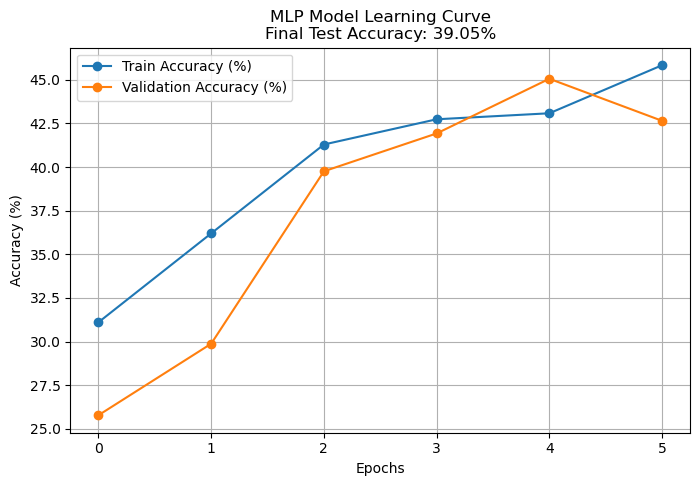

In [48]:
# Add your code to evaluate the MLP model using appropriate metrics and learning curves.

import matplotlib.pyplot as plt

# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(test_generator)


Val_loss, Val_accuracy = model.evaluate(val_generator)


# Convert accuracy values to percentages
test_accuracy_percent = test_accuracy * 100
train_accuracy_percent = [acc * 100 for acc in history.history['accuracy']]
val_accuracy_percent = [acc * 100 for acc in history.history['val_accuracy']]

# Print numerical results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy_percent:.2f}%") 
print(f"Val Loss: {Val_loss:.4f}")
print(f"Val Accuracy: {val_accuracy_percent[-1]:.2f}%")  # Display accuracy as percentage

# Plot learning curves with percentages
plt.figure(figsize=(8, 5))
plt.plot(train_accuracy_percent, label='Train Accuracy (%)', marker='o')
plt.plot(val_accuracy_percent, label='Validation Accuracy (%)', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title(f"MLP Model Learning Curve\nFinal Test Accuracy: {test_accuracy_percent:.2f}%")
plt.grid(True)
plt.show()

[Present the final accuracy obtained with the basic MLP model here]

### C: Human-Level Performance Accuracy

[Explain how you calculated the human-level performance accuracy here]

I write 40 questions each class 10 questons and then I send it to 5 different people to answer it and out of all the people who answered there was 26 incorrect so 5 times 40 devided by 26 is going to be 87%

**The HLP is 87%**

## Task 3.3: Basic Convolutional Neural Network (Iteration 1)

### A: Preprocessing

[Explain the preprocessing steps here (if any preprocessing is needed)]
For the preprocessing step, I normalized and rescaled all images to a range of 0-255. I also set the image input size to 256×256 pixels. While this increases computational cost compared to smaller dimensions like 64×64 or 128×128, it helps the model capture finer visual details, which is especially important for accurate skin type classification.

Additionally, I chose a batch size of 16 instead of the more common size of 32. A smaller batch size typically results in more stable and precise gradient updates, as the model adjusts weights more frequently. Although this can increase training time and require more memory per sample, it often leads to better generalization and improved model performance, particularly beneficial in tasks like skin type classification, where subtle visual differences are key. By prioritizing accuracy and detail over speed, this choice supports the goal of building a more reliable model.

Since my dataset includes four distinct classes (e.g., normal, dry, oily, and diseased skin types), I configured the model to use categorical mode for classification. This is necessary because the task is multi-class rather than binary.
In a binary classification problem, the output layer typically contains a single neuron with a sigmoid activation function, producing a probability between 0 and 1 for just two possible outcomes (e.g., positive or negative). However, in my case, this approach is not suitable, as there are more than two possible labels.

In [49]:
import os
# Add your code to preprocess your dataset for the basic CNN model.

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths (after splitting)
split_dataset_path = os.path.join(DATA_DIR, "split")

# Image parameters
image_size = (256, 256)  # Resize images for model input
batch_size = 16 # Number of images per batch

# Data generators for loading images
datagen = ImageDataGenerator(rescale=1./255)  # No augmentation for validation & test

# Load images from the split dataset
train_generator = datagen.flow_from_directory(
    directory=f"{split_dataset_path}/train",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True  # Change to 'categorical' for multi-class classification
)

val_generator =datagen.flow_from_directory(
    directory=f"{split_dataset_path}/val",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    directory=f"{split_dataset_path}/test",
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Do not shuffle test data for consistent evaluation
)

print("Split dataset successfully loaded!")

Found 1453 images belonging to 4 classes.
Found 415 images belonging to 4 classes.
Found 210 images belonging to 4 classes.
 Split dataset successfully loaded!


### B: CNN Architecture

[Explain your strategy to establish the architecture of the first CNN model here]

For my first CNN I wanted a network deep enough to pick up both simple and more complex features from the skin images. I used several convolutional blocks, each one a Conv2D layer followed by Batch Normalization and MaxPooling. This pulls out features, keeps training stable and shrinks the feature maps step by step.

I started with 32 filters in the first block and went up to 512 in the deeper layers, so the network can learn more abstract features as it goes deeper.

After the conv layers I added a Dropout of 0.5 to reduce overfitting, since the model gets quite complex by then.

The Flatten layer turns the feature maps into a 1D vector, then it goes through a few dense layers with ReLU. I used Batch Normalization and Dropout here too.

The output is a Dense layer with 4 neurons and softmax for the four classes. Overall I tried to keep a balance between depth and regularization for this task.

In [52]:
# Add your code to create a CNN architecture for your image dataset exploring multiple layer types.

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define CNN Model
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 4
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.5),

    # Flatten & Fully Connected Layers
    Flatten(),
    # Dense(512, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.6),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),
    # Dense(128, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Output Layer
    Dense(4, activation='softmax')  # Adjust number of classes as needed
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()


Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 254, 254, 32)      896       
                                                                 
 batch_normalization_43 (Ba  (None, 254, 254, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_10 (MaxPooli  (None, 127, 127, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_11 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_44 (Ba  (None, 125, 125, 64)      256       
 tchNormalization)                                               
                                                     

### C: CNN Training

[Explain your strategy to train a CNN model for the image classification problem here]

Here I trained the CNN on the training and validation sets. To make it more efficient and avoid overfitting I used early stopping.

Early stopping watches the validation loss. If it does not improve for 5 epochs the training stops, so the model does not keep going for nothing. With restore_best_weights=True it keeps the weights from the best epoch.

I set a maximum of 30 epochs with batch size 16, which is a good balance for memory and how often the weights update. I used verbose=1 so I could watch the accuracy and loss each epoch.

The idea was to get decent performance while keeping training efficient and generalizing well to new data.

In [53]:
# Add your code to train the CNN model using proper loss functions, optimizers, and hyperparameters.
# Train the CNN

from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    batch_size=16,  
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/30
91/91 [==============================] - 37s 389ms/step - loss: 1.4773 - accuracy: 0.4178 - val_loss: 5.4512 - val_accuracy: 0.2627
Epoch 2/30
91/91 [==============================] - 36s 397ms/step - loss: 1.2251 - accuracy: 0.5024 - val_loss: 2.6098 - val_accuracy: 0.2723
Epoch 3/30
91/91 [==============================] - 35s 380ms/step - loss: 1.2054 - accuracy: 0.4845 - val_loss: 2.2279 - val_accuracy: 0.3181
Epoch 4/30
91/91 [==============================] - 34s 372ms/step - loss: 1.1120 - accuracy: 0.5306 - val_loss: 1.5673 - val_accuracy: 0.3639
Epoch 5/30
91/91 [==============================] - 34s 376ms/step - loss: 1.0692 - accuracy: 0.5244 - val_loss: 1.2451 - val_accuracy: 0.4169
Epoch 6/30
91/91 [==============================] - 35s 380ms/step - loss: 1.0554 - accuracy: 0.5313 - val_loss: 1.0643 - val_accuracy: 0.4699
Epoch 7/30
91/91 [==============================] - 34s 372ms/step - loss: 1.0301 - accuracy: 0.5554 - val_loss: 1.0670 - val_accuracy: 0.4747

### D: Model Evaluation

[Explain your strategy to evaluate the CNN model here]

After training the CNN I wanted to see how it does on data it never saw, so I evaluated it on the test set and also checked the validation set.

The test accuracy was about 59%, so the model got the skin type right roughly 59 times out of 100 on the test images. I looked at the validation accuracy and loss too, to make sure it was not just overfitting.

To see where it went wrong I used a confusion matrix. It showed that the model did very well on one class but mixed up the others, especially the skin types that look alike.

I also used a classification report for precision, recall and F1 per class. That told me how balanced the predictions were.

So my evaluation was: accuracy and loss on test and validation, a confusion matrix and classification report for per class results, and the learning curves to check for overfitting. This gave me a good idea of what the model does well and where it struggles.

In [54]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels & predictions
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred))


14/14 [==============================] - 2s 120ms/step
Confusion Matrix:
 [[27  9 15  1]
 [20 19 12  0]
 [18 12 22  0]
 [ 0  0  0 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.42      0.52      0.46        52
           1       0.47      0.37      0.42        51
           2       0.45      0.42      0.44        52
           3       0.98      1.00      0.99        55

    accuracy                           0.59       210
   macro avg       0.58      0.58      0.58       210
weighted avg       0.59      0.59      0.58       210



26/26 [==============================] - 3s 129ms/step - loss: 0.8416 - accuracy: 0.5783
 Test Loss: 0.8570
 Test Accuracy: 58.57%
 Val Loss: 0.8416
 Val Accuracy: 58.07%


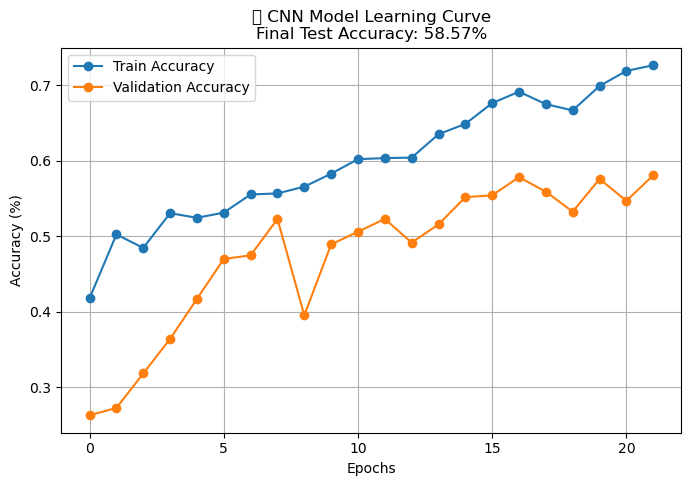

In [56]:
import matplotlib.pyplot as plt

# Evaluate the CNN model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)

Val_loss, Val_accuracy = model.evaluate(val_generator)


# Convert accuracy values to percentages
test_accuracy_percent = test_accuracy * 100
train_accuracy_percent = [acc * 100 for acc in history.history['accuracy']]
val_accuracy_percent = [acc * 100 for acc in history.history['val_accuracy']]

# Print numerical results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy_percent:.2f}%") 
print(f"Val Loss: {Val_loss:.4f}")
print(f"Val Accuracy: {val_accuracy_percent[-1]:.2f}%")  # Display accuracy as percentage


# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title(f"CNN Model Learning Curve\nFinal Test Accuracy: {test_accuracy_percent:.2f}%")
plt.grid(True)
plt.show()


[Explain the results obtained with your first CNN model]

14/14 [==============================] - 2s 110ms/step - loss: 0.8570 - accuracy: 0.5857
26/26 [==============================] - 3s 129ms/step - loss: 0.8416 - accuracy: 0.5783
Test Loss: 0.8570
Test Accuracy: 58.57%
Val Loss: 0.8416
Val Accuracy: 58.07%

I also explained in previous cell.

## Task 3.4: Data Augmentation (Iteration 2)

### A: Preprocessing

[Explain the preprocessing steps to use data augmentation in this iteration here]

To help the model generalize better I added data augmentation on the chosen classes: dry_skin, normal_skin, oily_skin and skin diseas. I picked these because of class imbalance and to add more variation. For each image I applied rotation, zoom, brightness change, horizontal flip and width/height shift, to copy real world variation. For every original image I made 3 augmented ones and saved them in a new folder called aug_train.

After the augmentation finished (the output said "Augmentation process complete!") I set up the data with ImageDataGenerator. I rescaled the pixels with 1./255 so the values are between 0 and 1, which helps training.

The augmented training set had 4,151 images across 4 classes, so the augmentation clearly increased the data a lot.

The validation set had 415 images and the test set 210, both only rescaled and not augmented.

I used categorical class mode because it is a multi class problem, and I turned off shuffling on validation and test so the order stays the same when I evaluate.

So the model trained on a bigger and more varied set, while the validation and test data stayed clean for a fair check.

In [28]:
# Add your code to preprocess your dataset for the CNN model using Data Augmentation.

import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Classes to be augmented
augment_classes = ['dry_skin', 'normal_skin', 'oily_skin', 'skin diseas']

# Paths
dataset_path = os.path.join(DATA_DIR, "split", "train")
augmented_dataset_path = os.path.join(DATA_DIR, "split", "aug_train")

# Create the output folder if it doesn't exist
os.makedirs(augmented_dataset_path, exist_ok=True)

# Data Augmentation Configuration
augment_datagen = ImageDataGenerator(
    rotation_range=20,
    rescale=1./255,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    fill_mode='nearest',
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

# Normal Data Generator (No Augmentation)
normal_datagen = ImageDataGenerator(rescale=1./255)

# Loop through each class folder
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)
    new_class_path = os.path.join(augmented_dataset_path, class_name)
    
    # Create corresponding folder in new dataset
    os.makedirs(new_class_path, exist_ok=True)
    
    if class_name in augment_classes:
        print(f"Applying augmentation to: {class_name}")

        # Load images in the selected class
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            # Load image properly
            try:
                img = image.load_img(img_path, target_size=(256, 256))  # Resize images
                img_array = image.img_to_array(img)  # Convert to array
                img_array = np.expand_dims(img_array, axis=0)  # Expand dims for augmentation

                # Generate augmented images
                i = 0
                for batch in augment_datagen.flow(img_array, batch_size=1, 
                                                  save_to_dir=new_class_path, 
                                                  save_prefix="aug", 
                                                  save_format="jpg"):
                    i += 1
                    if i >= 3:  # Save 3 augmented versions per image
                        break
            except Exception as e:
                print(f"Error processing {img_name}: {e}")

    else:
        print(f"Copying images without augmentation: {class_name}")

        # Copy images directly without augmentation
        for img_name in os.listdir(class_path):
            src_path = os.path.join(class_path, img_name)
            dest_path = os.path.join(new_class_path, img_name)

            # Ensure it's an image file before copying
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(src_path, dest_path)

print("Augmentation process complete!")




Applying augmentation to: dry_skin
Applying augmentation to: normal_skin
Applying augmentation to: oily_skin
Applying augmentation to: skin diseas
 Augmentation process complete!


In [57]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
augmented_dataset_path = os.path.join(DATA_DIR, "split", "aug_train")
val_path=os.path.join(DATA_DIR, "split", "val")
test_path=os.path.join(DATA_DIR, "split", "test")

# Define ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255  # Normalize pixel values (0-1)
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load Augmented Dataset
train_generator = train_datagen.flow_from_directory(
    augmented_dataset_path,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical',  # Use 80% of data for training
)

val_generator = train_datagen.flow_from_directory(
    val_path,
    target_size=(256, 256),
    batch_size=16,
    class_mode='categorical',
    shuffle=False # Use 20% for validation
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(256,256),
    batch_size=16,
    class_mode='categorical',
    shuffle=False  # Do not shuffle test data for consistent evaluation
)

Found 4151 images belonging to 4 classes.
Found 415 images belonging to 4 classes.
Found 210 images belonging to 4 classes.


### B: CNN Architecture

[Explain your strategy to establish the architecture of the CNN model here]

I built this CNN step by step to pull good features out of the skin images. I started with four convolutional blocks. The early layers find edges and textures, the deeper ones find more complex patterns. After each conv layer I used batch normalization to keep the outputs in a steady range, and max pooling to shrink the feature maps and lower the compute cost.

As the network goes deeper I raised the number of filters (from 32 up to 256) so it can learn more detailed features. After the last conv block I used a flatten layer to make a 1D vector for the dense part.

In the dense part I added two layers, 256 and 64 neurons, each with batch normalization and dropout. Dropout turns off some neurons during training so the model does not just memorize the training data. The output is 4 neurons with softmax, one per skin type.

I wanted the model deep enough to learn the patterns but still regularized so it does not overfit. It ended up with around 13 million parameters, which is fine for 256x256 images.

In [60]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Define CNN Model
model = Sequential([
    # Convolutional Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Convolutional Block 4
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    # Conv2D(512, (3,3), activation='relu'),
    # BatchNormalization(),
    # MaxPooling2D(pool_size=(2,2)),
    # Dropout(0.5),

    # Flatten & Fully Connected Layers
    Flatten(),
    # Dense(512, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.6),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.6),
    # Dense(128, activation='relu'),
    # BatchNormalization(),
    # Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Output Layer
    Dense(4, activation='softmax')  # Adjust number of classes as needed
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show model architecture
model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_20 (Conv2D)          (None, 254, 254, 32)      896       
                                                                 
 batch_normalization_57 (Ba  (None, 254, 254, 32)      128       
 tchNormalization)                                               
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 127, 127, 32)      0         
 ng2D)                                                           
                                                                 
 conv2d_21 (Conv2D)          (None, 125, 125, 64)      18496     
                                                                 
 batch_normalization_58 (Ba  (None, 125, 125, 64)      256       
 tchNormalization)                                               
                                                     

### C: CNN Training

[Explain your strategy to train a CNN model for your image classification problem here]

To train this CNN I used the augmented training set so it sees more variety and generalizes better. I trained for up to 30 epochs with early stopping to avoid overfitting. Early stopping watched the validation loss, and if it did not improve for 5 epochs the training stopped and the best weights were restored. That way I did not waste time and the model did not just memorize the data.

I used batch size 16, which was a good balance between stable training and compute cost. The model trained on the augmented data and was validated on a clean set. The training accuracy went up over 66% and the validation accuracy peaked around 58%. The validation loss jumped around a bit, but the model still did better than my earlier runs without augmentation.

So the plan was: augmented images, dropout and batch normalization for regularization, and early stopping, while watching both training and validation to know when to stop.

In [61]:
# Add your code to train the CNN model using proper loss functions, optimizers, and hyperparameters.
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with augmented data
history_augmented = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,  # Increased epochs for better learning
    batch_size=16,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/30
260/260 [==============================] - 100s 376ms/step - loss: 1.4002 - accuracy: 0.4428 - val_loss: 3.0921 - val_accuracy: 0.2988
Epoch 2/30
260/260 [==============================] - 98s 376ms/step - loss: 1.2036 - accuracy: 0.4758 - val_loss: 1.1644 - val_accuracy: 0.4627
Epoch 3/30
260/260 [==============================] - 98s 375ms/step - loss: 1.0639 - accuracy: 0.5175 - val_loss: 1.0188 - val_accuracy: 0.5205
Epoch 4/30
260/260 [==============================] - 98s 378ms/step - loss: 0.9949 - accuracy: 0.5387 - val_loss: 1.4297 - val_accuracy: 0.4651
Epoch 5/30
260/260 [==============================] - 97s 373ms/step - loss: 0.9772 - accuracy: 0.5531 - val_loss: 1.0539 - val_accuracy: 0.5277
Epoch 6/30
260/260 [==============================] - 97s 372ms/step - loss: 0.9476 - accuracy: 0.5541 - val_loss: 1.0574 - val_accuracy: 0.5229
Epoch 7/30
260/260 [==============================] - 91s 350ms/step - loss: 0.8942 - accuracy: 0.5890 - val_loss: 0.9623 - val_a

### D: Model Evaluation

[Explain your strategy to evaluate the CNN model here]

To check this CNN I used numbers, learning curves and a per class look. First I evaluated it on the test and validation sets. The test accuracy was about 56.19% and the validation about 58.07%, so it generalizes okay but there is room to improve.

To see how it learned I plotted the training and validation accuracy over the epochs, and the loss curves too, to spot overfitting or underfitting.

Then I used a confusion matrix to see how each class did. Class 3 (skin disease) had very high accuracy and recall, while normal, dry and oily skin scored lower. So the model seems to favor the classes that are easier to tell apart.

Finally I used a classification report with precision, recall and F1 per class. For example class 1 had a high recall, but class 0 had a low recall and was often misclassified.

So I looked at the overall result and the per class strengths and weaknesses, which showed me where the model is fine and where I need more tuning or better data balance.

26/26 [==============================] - 3s 115ms/step - loss: 0.9428 - accuracy: 0.5807
 Test Loss: 0.9047
 Test Accuracy: 56.19%
 Val Loss: 0.9428
 Val Accuracy: 58.07%


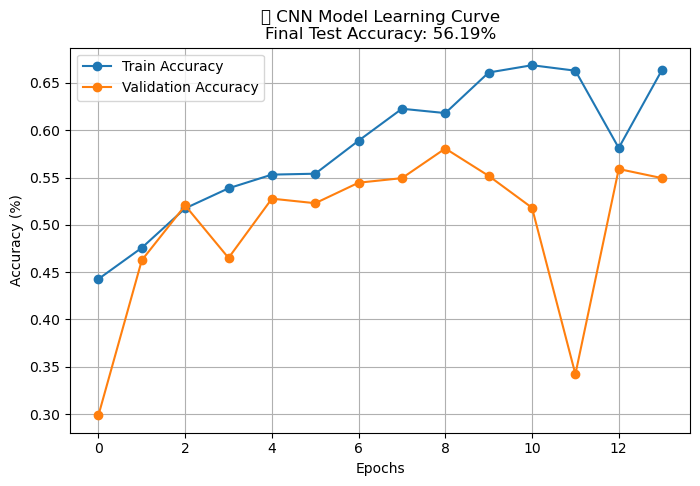

Text(0.5, 1.0, 'Loss Curve')

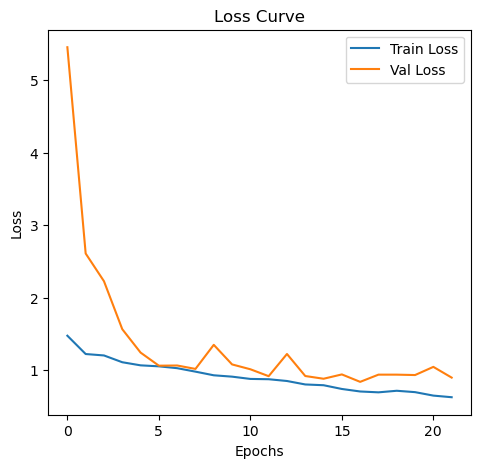

In [62]:
# Add your code to evaluate the CNN model using appropriate metrics and learning curves.

import matplotlib.pyplot as plt

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_generator)


Val_loss, Val_accuracy = model.evaluate(val_generator)


# Convert accuracy values to percentages
test_accuracy_percent = test_accuracy * 100
train_accuracy_percent = [acc * 100 for acc in history.history['accuracy']]
val_accuracy_percent = [acc * 100 for acc in history.history['val_accuracy']]

# Print numerical results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy_percent:.2f}%") 
print(f"Val Loss: {Val_loss:.4f}")
print(f"Val Accuracy: {val_accuracy_percent[-1]:.2f}%")  # Display accuracy as percentage

# Plot learning curves
plt.figure(figsize=(8, 5))
plt.plot(history_augmented.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history_augmented.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.title(f"CNN Model Learning Curve\nFinal Test Accuracy: {test_accuracy_percent:.2f}%")
plt.grid(True)
plt.show()
# Plot Training & Validation Loss/Accuracy
plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")


In [63]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get True Labels & Predictions
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Classification Report
print("Classification Report:\n", classification_report(y_true, y_pred))


14/14 [==============================] - 2s 106ms/step
Confusion Matrix:
 [[11 19 17  5]
 [ 8 30 11  2]
 [ 4 22 24  2]
 [ 2  0  0 53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.21      0.29        52
           1       0.42      0.59      0.49        51
           2       0.46      0.46      0.46        52
           3       0.85      0.96      0.91        55

    accuracy                           0.56       210
   macro avg       0.54      0.56      0.54       210
weighted avg       0.55      0.56      0.54       210



[Explain the results obtained with the CNN model for this iteration here]
In this iteration the CNN got a test accuracy of 56.19% and a validation accuracy of 58.07%, so the performance was moderate. The model learned and generalized to some extent, but there is still clear room to improve, mostly for some classes.

From the confusion matrix I saw that the model did well on class 3 (skin disease), most predictions were correct. The classification report backed this up with precision 0.85 and recall 0.96 for that class. It struggled with dry, normal and oily skin, where precision and recall were lower. For example class 0 (dry skin) had a recall of only 0.21, so the model often missed it.

The learning curves showed that training and validation accuracy went up in the first epochs, but then the validation started to jump around and did not keep improving, which points to overfitting or imbalance. The loss curve agreed, since the validation loss did not keep going down after a point.

So the model is promising for some classes but not consistent across all four. It needs better data balance, maybe a different architecture, or some hyperparameter tuning to do better on the harder classes.

## Task 3.5: Transfer Learning (Iteration 3)

### A: Preprocessing

[Explain the preprocessing steps performed to use transfer learning in this iteration here (if needed)]

In this iteration I prepared the data for transfer learning with VGG16, which needs a fixed input format. I resized all images to 224x224, which is the size VGG16 expects, so they fit the pretrained network.

I used ImageDataGenerator to load the images and rescale the pixels to the [0, 1] range. The generator can also do augmentation, but here I only used rescaling so the pretrained model can focus on the main patterns.

I made three generators, for training, validation and test, all with the same preprocessing. I turned off shuffling for the validation and test generators so the class order stays the same when I evaluate.

In [67]:
import os
# Add your code to preprocess the dataset for the CNN model.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths
normal_dataset_path = os.path.join(DATA_DIR, "split", "train")
val_path=os.path.join(DATA_DIR, "split", "val")
test_path=os.path.join(DATA_DIR, "split", "test")

# Define ImageDataGenerators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=20,  # Rotate images randomly  # Shift vertically
    # shear_range=0.2,  # Apply shearing
    # zoom_range=0.2,  # Random zoom
    # horizontal_flip=True,  # Flip horizontally
    # fill_mode='nearest'  # Fill missing pixels  # Normalize pixel values (0-1)
)

# Load Augmented Dataset
train_generator = train_datagen.flow_from_directory(
    normal_dataset_path,
    target_size=(224, 224), #it is predefined for this model
    batch_size=16,
    class_mode='categorical'  # Use 80% of data for training
)

val_generator = train_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False  # Use 20% for validation
)
test_generator = train_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False  # Do not shuffle test data for consistent evaluation
)

Found 1453 images belonging to 4 classes.
Found 415 images belonging to 4 classes.
Found 210 images belonging to 4 classes.


### B: CNN Architecture

[Explain your strategy to establish the architecture of the CNN model using transfer learning here]

Here I used transfer learning with VGG16 to reuse the features it already learned from ImageNet. I froze all the convolutional layers of VGG16, so they are not updated during training and just act as a fixed feature extractor for edges, textures and shapes.

On top of the frozen base I added my own dense layers for my task of 4 skin types. First a Flatten layer to turn the VGG16 output into a 1D vector. Then Dense layers (512, 256 and 128 units) with ReLU so the model can combine the extracted features.

To keep it stable and reduce overfitting I put Batch Normalization and Dropout between the dense layers.

The output is a Dense layer with 4 neurons and softmax, so the model gives a probability for each skin type and picks the highest one.

In [68]:
# Add your code to create a CNN architecture for your image dataset.

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout,BatchNormalization

# Load VGG16 model without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


# Freeze all convolutional layers (Feature Extraction)
for layer in base_model.layers:
    layer.trainable = False

# Add Custom Fully Connected Layers for Skin Type Classification
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(4, activation='softmax')(x)  # 4 classes

# Create Model
model = Model(inputs=base_model.input, outputs=output_layer)


### C: CNN Training

[Explain your strategy to train the CNN model for your image classification problem here]

In this iteration I trained with transfer learning on VGG16. I froze most of the VGG16 layers and only fine tuned the last 6, so the model could adapt to my skin type task while keeping the features it learned from ImageNet. On top I added my own dense layers with batch normalization and dropout to reduce overfitting. I used Adam with a very low learning rate (0.00003) so the updates stay careful. I also used class weights to deal with the class imbalance, and two callbacks, early stopping and ReduceLROnPlateau, to keep training stable and avoid overfitting. During training the accuracy went up from about 35% to over 74% on the training set, and the validation accuracy reached about 68.67%. The validation loss settled down in the later epochs, so the model was generalizing well. This showed me that fine tuning a pretrained model with the right settings can really boost performance on a custom task.

In [ ]:
# Add your code to train the CNN model using proper loss functions, optimizers, and hyperparameters.
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

for layer in base_model.layers[-6:]: #-12
    layer.trainable = True
# Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.00003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', patience=2, factor=0.5, verbose=1
)


In [70]:
from sklearn.utils import class_weight
import numpy as np

# Get labels as integers (not one-hot)
# If you're using a generator like `train_generator`, you can use:
y_train_labels = train_generator.classes  # These are your actual class indices

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to dictionary
class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)


Class Weights: {0: 1.0062326869806095, 1: 1.0290368271954675, 2: 1.0146648044692737, 3: 0.9534120734908137}


In [71]:
from sklearn.utils import class_weight
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stopping,lr_scheduler],
    class_weight=class_weights_dict,
    verbose=1
)


Epoch 1/30
91/91 [==============================] - 96s 1s/step - loss: 2.3497 - accuracy: 0.3510 - val_loss: 1.1180 - val_accuracy: 0.4892 - lr: 3.0000e-05
Epoch 2/30
91/91 [==============================] - 94s 1s/step - loss: 1.8071 - accuracy: 0.4109 - val_loss: 0.9925 - val_accuracy: 0.4892 - lr: 3.0000e-05
Epoch 3/30
91/91 [==============================] - 94s 1s/step - loss: 1.5279 - accuracy: 0.4508 - val_loss: 0.9589 - val_accuracy: 0.5277 - lr: 3.0000e-05
Epoch 4/30
91/91 [==============================] - 95s 1s/step - loss: 1.3928 - accuracy: 0.4680 - val_loss: 0.9549 - val_accuracy: 0.5494 - lr: 3.0000e-05
Epoch 5/30
91/91 [==============================] - 94s 1s/step - loss: 1.2939 - accuracy: 0.4914 - val_loss: 0.9180 - val_accuracy: 0.5470 - lr: 3.0000e-05
Epoch 6/30
91/91 [==============================] - 95s 1s/step - loss: 1.2048 - accuracy: 0.4962 - val_loss: 0.9169 - val_accuracy: 0.5301 - lr: 3.0000e-05
Epoch 7/30
91/91 [==============================] - 96s 1s

### D: Model Evaluation

[Explain your strategy to evaluate the CNN model for this iteration here]

After training with transfer learning I checked the model with a few metrics and plots. First I tested it on the test set, where it got 64.76% accuracy and a loss of 0.7666, which is solid. The best run during training was at epoch 29, with validation accuracy 68.67% and the lowest validation loss 0.7602, so the training was stable.

To see how it learned I plotted the loss and accuracy curves for training and validation. They improved steadily with no big sign of overfitting, and training and validation stayed close.

For a deeper look I used a confusion matrix over the four classes. The model did very well on class 3 (skin disease), with recall 0.98 and precision 0.96, so it caught almost all of those. It had more trouble telling apart classes 0, 1 and 2 (dry, normal and oily skin), where precision and recall were lower but still okay, with F1 between 0.47 and 0.59.

The classification report showed an overall accuracy of 65% and a macro and weighted F1 of 0.64, so the model was fairly consistent. This iteration showed me that VGG16 transfer learning works well for this multi class task with decent and balanced results.

26/26 [==============================] - 16s 584ms/step - loss: 0.7673 - accuracy: 0.6530
 Test Loss: 0.7666
 Test Accuracy: 56.19%
 Best Model Performance at Epoch 29
 Best Validation Accuracy: 68.67%
 Best Validation Loss: 0.7602


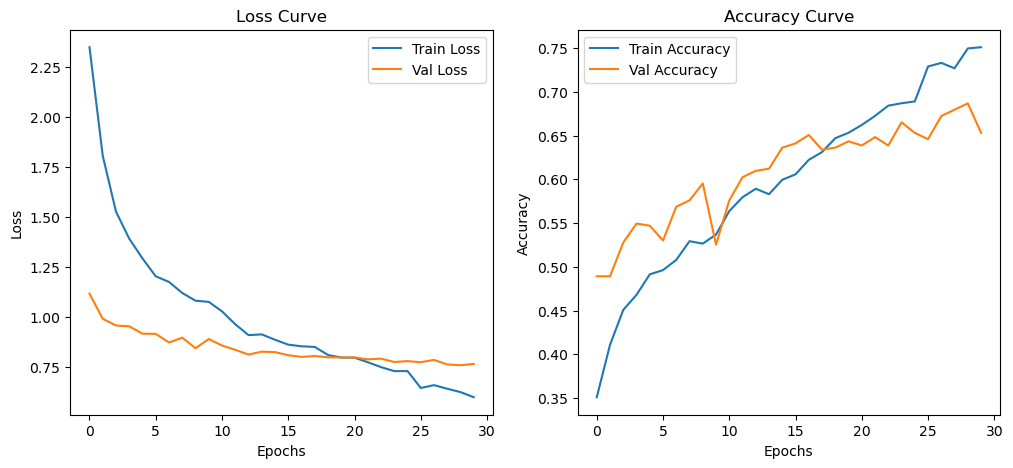

In [72]:
# Add your code to evaluate the CNN model using appropriate metrics and learning curves.
import numpy as np
import matplotlib.pyplot as plt
# Plot Loss & Accuracy

test_loss, test_accuracy = model.evaluate(test_generator)


Val_loss, Val_accuracy = model.evaluate(val_generator)

test_accuracy_percent = test_accuracy * 100

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy_percent:.2f}%") 

print(f"Best Model Performance at Epoch {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"Best Validation Loss: {best_val_loss:.4f}")
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [73]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

14/14 [==============================] - 8s 542ms/step - loss: 0.7666 - accuracy: 0.6476
 Test Loss: 0.7666
 Test Accuracy: 64.76%


In [74]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get true labels & predictions
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", conf_matrix)

# Print classification report
print("Classification Report:\n", classification_report(y_true, y_pred))

14/14 [==============================] - 8s 542ms/step
Confusion Matrix:
 [[32 11  8  1]
 [15 24 12  0]
 [ 8 17 26  1]
 [ 1  0  0 54]]
Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.62      0.59        52
           1       0.46      0.47      0.47        51
           2       0.57      0.50      0.53        52
           3       0.96      0.98      0.97        55

    accuracy                           0.65       210
   macro avg       0.64      0.64      0.64       210
weighted avg       0.65      0.65      0.65       210



[Explain the results obtained with the CNN model for this iteration here]

## Task 3.6: Model Improvement (Iteration 4)

### A: Preprocessing

[Explain the preprocessing steps performed for this iteration here (if needed)]
Same as previous cell iteration

In [53]:
import os
# Add your code to preprocess the dataset for the CNN model.

# Define paths
normal_dataset_path = os.path.join(DATA_DIR, "split", "train")
val_path=os.path.join(DATA_DIR, "split", "val")
test_path=os.path.join(DATA_DIR, "split", "test")
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


# === 1. Data Generators ===
train_datagen = ImageDataGenerator(
    rescale=1./255,
    # rotation_range=10,
    # zoom_range=0.2,
    # width_shift_range=0.1,
    # height_shift_range=0.1,
    # horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    normal_dataset_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)


Found 1453 images belonging to 4 classes.
Found 415 images belonging to 4 classes.


### B: CNN Architecture

[Explain your strategy to establish the architecture of the CNN model for this iteration here]

In this iteration I used VGG19 as the base for my CNN. VGG19 is a deep pretrained network trained on ImageNet and it is good at extracting features. I set include_top=False so I could drop its original classifier and add my own for the 4 classes. I also froze the base at first, so only my top layers train. This way I keep the pretrained features while my classifier learns to map them to the skin types.

On top of VGG19 I added my own dense layers, starting with a Flatten layer to make a 1D vector. Then three dense layers (512, 256 and 128 units) with ReLU for non linearity. I added dropout (0.6, 0.5 and 0.5) after each dense layer to fight overfitting, and batch normalization after the first dense layer to keep training stable. The last layer is Dense with 4 units and softmax for the four classes.

To train I used Adam with a small learning rate of 0.00005, which fits fine tuning a deep pretrained model. The loss is categorical crossentropy for multi class with one hot labels, and I tracked accuracy.

In [12]:
base_model = VGG19(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False  # Freeze the base model initially

In [16]:
# Add your code to create the CNN architecture for your image dataset.
# Add Custom Fully Connected Layers for Skin Type Classification
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.6)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)  # 4 classes

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.00005),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# model.compile(optimizer=Adam(learning_rate=1e-4),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

### C: CNN Training

[Explain your strategy to train a CNN model for your image classification problem here]

In this training phase I used transfer learning with VGG19 as the base and only trained my own classifier head, keeping the convolutional base frozen. This let me reuse the general features from ImageNet, which reduces overfitting and keeps training efficient.

I compiled with Adam and a low learning rate of 0.00005, good for fine tuning. The loss is categorical crossentropy because it is multi class (4 skin types), and I tracked accuracy.

To make training smarter I used two callbacks:

EarlyStopping, to stop if the validation loss does not improve after 5 epochs, which prevents overfitting and saves time.

ReduceLROnPlateau, to cut the learning rate in half if the validation loss does not improve for 3 epochs, so the model can keep learning the smaller details when it slows down.

Over the 30 epochs the model kept improving. Accuracy went from about 36% to over 75% on the training set, and the validation accuracy peaked around 68%. The validation loss went down and settled, so it was learning real features and not overfitting. The learning rate drops also helped in the later epochs.

So this training combined frozen transfer learning, dropout and batch normalization, and learning rate control, which gave a model that generalizes better on new data.

In [17]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)

In [ ]:

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
91/91 [==============================] - 88s 961ms/step - loss: 2.1660 - accuracy: 0.3620 - val_loss: 1.2151 - val_accuracy: 0.3542 - lr: 5.0000e-05
Epoch 2/30
91/91 [==============================] - 86s 946ms/step - loss: 1.6568 - accuracy: 0.4343 - val_loss: 1.0372 - val_accuracy: 0.5205 - lr: 5.0000e-05
Epoch 3/30
91/91 [==============================] - 85s 939ms/step - loss: 1.5134 - accuracy: 0.4336 - val_loss: 0.9780 - val_accuracy: 0.5229 - lr: 5.0000e-05
Epoch 4/30
91/91 [==============================] - 93s 1s/step - loss: 1.4599 - accuracy: 0.4632 - val_loss: 0.9920 - val_accuracy: 0.5398 - lr: 5.0000e-05
Epoch 5/30
91/91 [==============================] - 85s 936ms/step - loss: 1.3615 - accuracy: 0.4708 - val_loss: 0.9728 - val_accuracy: 0.5422 - lr: 5.0000e-05
Epoch 6/30
91/91 [==============================] - 85s 937ms/step - loss: 1.3169 - accuracy: 0.4914 - val_loss: 0.9327 - val_accuracy: 0.5904 - lr: 5.0000e-05
Epoch 7/30
91/91 [=========================

In [22]:
model.save("vgg19_skin_classifier_before_finetune.h5")


In [25]:
from tensorflow.keras.models import load_model
model = load_model("vgg19_skin_classifier_before_finetune.h5")


### D: Model Evaluation

After training with the VGG19 base I checked how it generalizes on the validation set. The best validation accuracy was 67.95% at epoch 29, with a best validation loss of 0.7920. I plotted the loss and accuracy curves, which improved steadily over the epochs, so the model was learning and not overfitting.

To see each class I made a classification report and a confusion matrix. The model did best on "skin disease", with precision 0.90 and recall 0.97, so it caught that class almost all the time. The other classes (dry, normal and oily skin) were more balanced but a bit lower, with F1 between 0.52 and 0.60. The macro and weighted F1 were both 0.66, so the model stayed fairly consistent across classes.

The confusion matrix heatmap showed where it got things right and where it got confused. It mixed up dry, normal and oily skin sometimes, which makes sense because they look similar, but it kept recognizing skin disease very well.

Finally I compared training and validation accuracy and loss with plots. If I fine tune later (history_finetune) those curves will help me compare unfreezing the base and training more. Overall the model does quite well, especially on the more distinct classes, and there is still room to improve with fine tuning or more balanced data.

26/26 [==============================] - 18s 664ms/step - loss: 0.7970 - accuracy: 0.6675
 Best Model Performance at Epoch 29
 Best Validation Accuracy: 67.95%
 Best Validation Loss: 0.7920


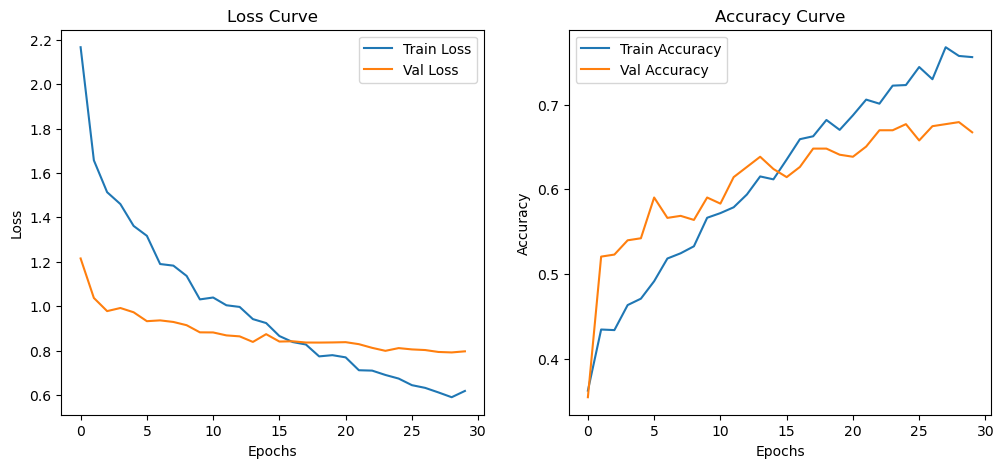

In [28]:
import numpy as np
import matplotlib.pyplot as plt
# Plot Loss & Accuracy



Val_loss, Val_accuracy = model.evaluate(val_generator)

best_epoch = np.argmax(history.history['val_accuracy']) + 1
best_val_acc = max(history.history['val_accuracy'])
best_val_loss = min(history.history['val_loss'])


print(f"Best Model Performance at Epoch {best_epoch}")
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")
print(f"Best Validation Loss: {best_val_loss:.4f}")
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

[Explain your strategy to evaluate the CNN model for this iteration here]

In [30]:
!pip install seaborn


[Explain the results obtained with the CNN model for this iteration here]

26/26 [==============================] - 17s 642ms/step

Classification Report:
              precision    recall  f1-score   support

    dry_skin       0.62      0.59      0.60       103
 normal_skin       0.53      0.62      0.58       101
   oily_skin       0.59      0.46      0.52       102
 skin diseas       0.90      0.97      0.93       109

    accuracy                           0.67       415
   macro avg       0.66      0.66      0.66       415
weighted avg       0.66      0.67      0.66       415



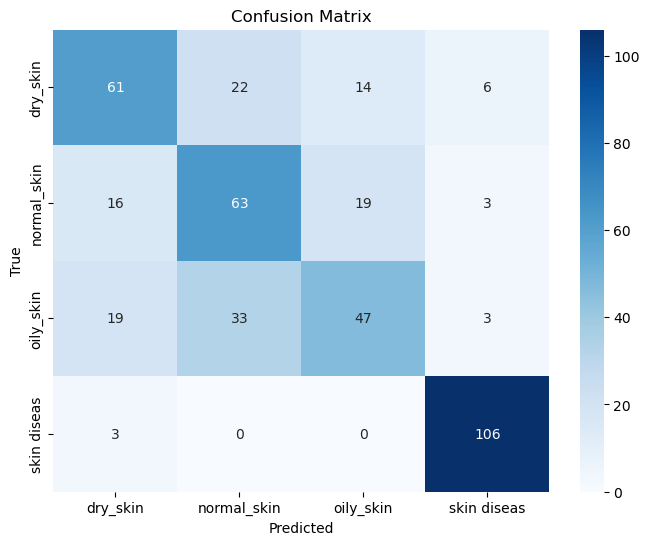

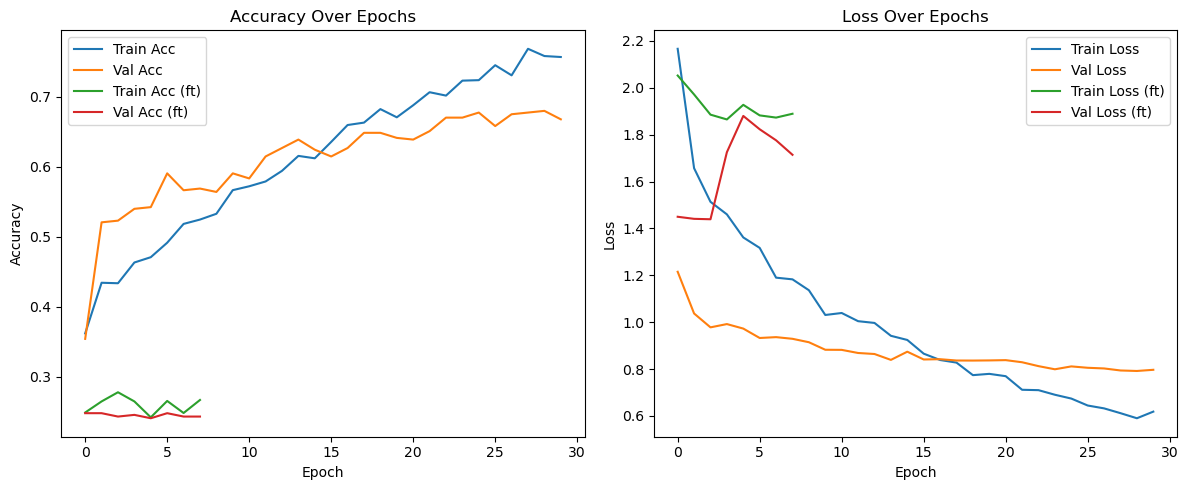

In [32]:
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Accuracy curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
if "history_finetune" in globals() and "accuracy" in history_finetune.history:
    plt.plot(history_finetune.history['accuracy'], label='Train Acc (ft)')
    plt.plot(history_finetune.history['val_accuracy'], label='Val Acc (ft)')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
if "history_finetune" in globals() and "loss" in history_finetune.history:
    plt.plot(history_finetune.history['loss'], label='Train Loss (ft)')
    plt.plot(history_finetune.history['val_loss'], label='Val Loss (ft)')
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()


## Task 3.7: Error Analysis

### A: Wrong Classifications


Total Misclassified Samples: 138


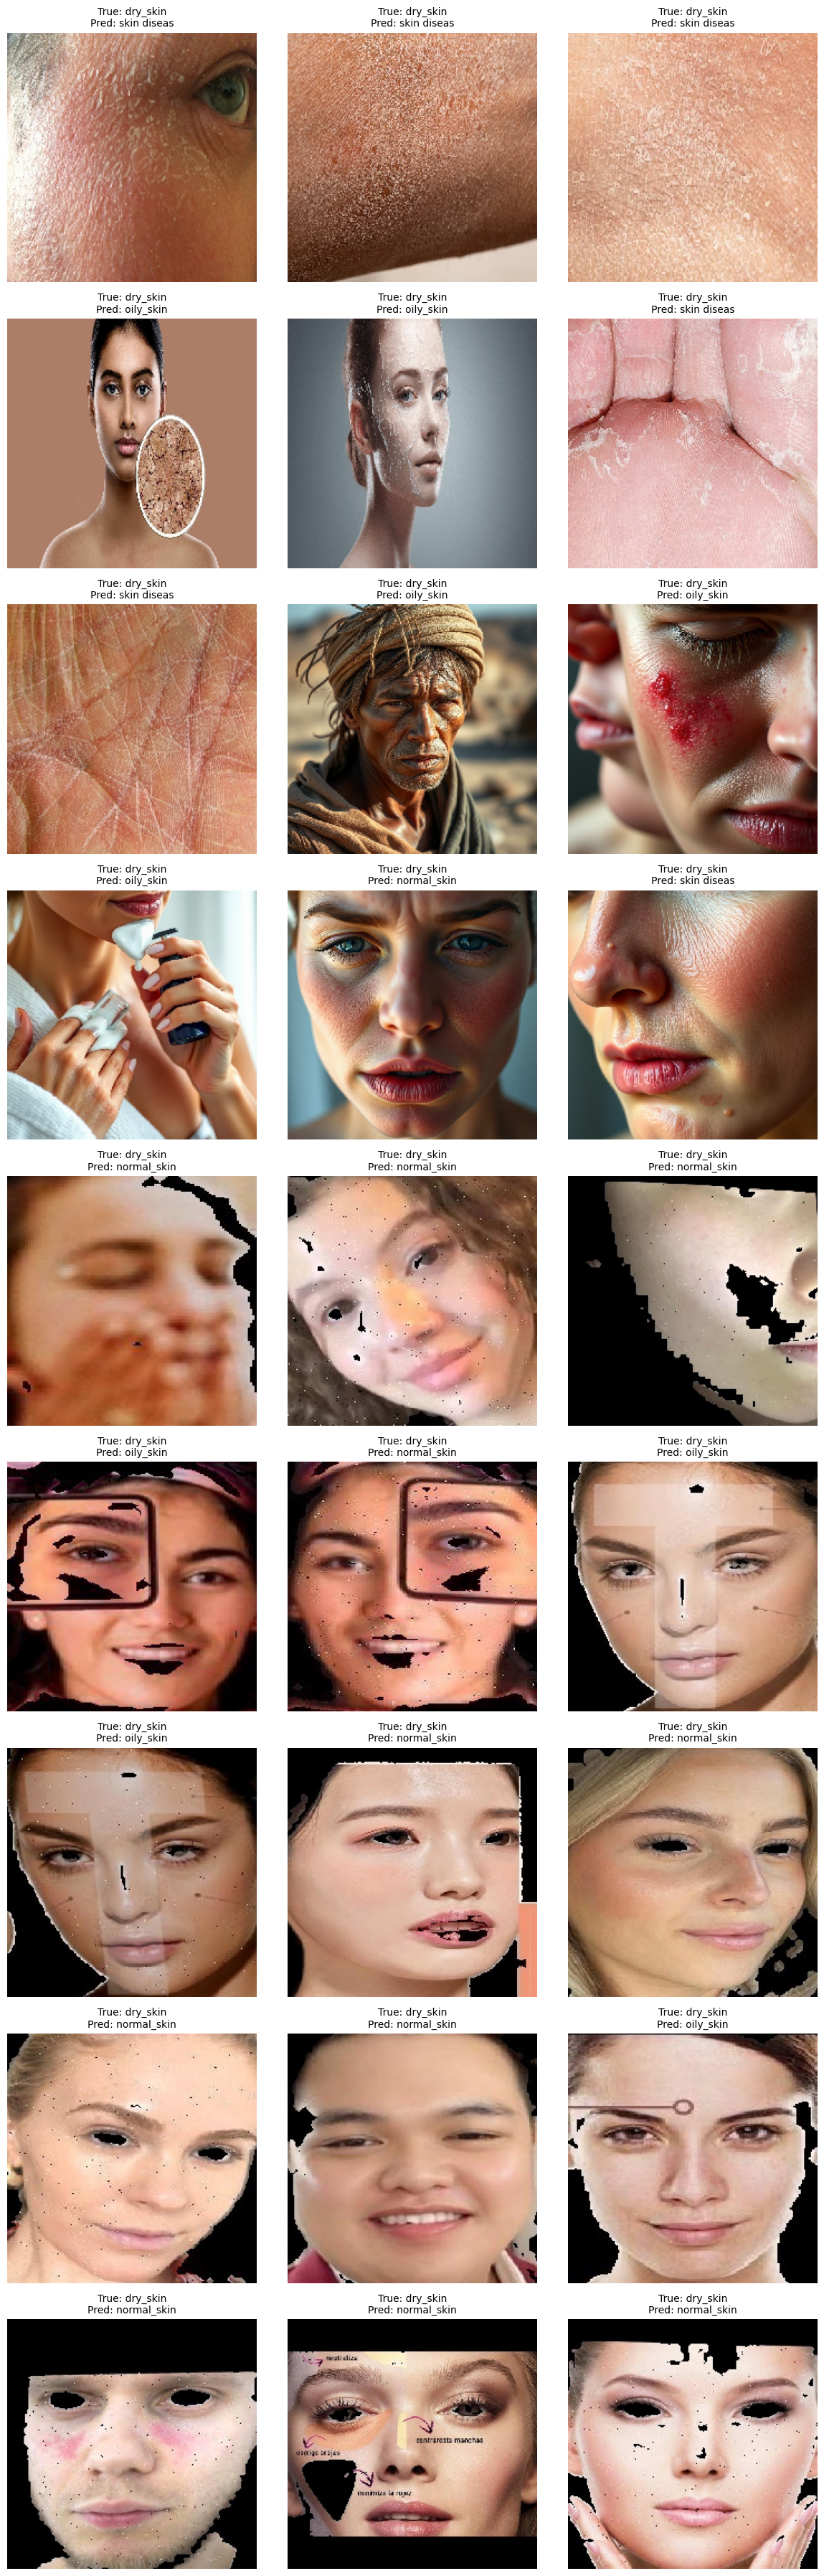

In [49]:
# Add your code identify and display the misclassified images of your best model
import math
# Step 1: Identify misclassified samples
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"\nTotal Misclassified Samples: {len(misclassified_indices)}")

n_images = 27 
rows = math.ceil(n_images / 3)  # 3 columns
plt.figure(figsize=(12, 4 * rows))

for i, idx in enumerate(misclassified_indices[:n_images]):
    image = val_generator[idx // val_generator.batch_size][0][idx % val_generator.batch_size]
    true_label = class_labels[y_true[idx]]
    pred_label = class_labels[y_pred[idx]]
    plt.subplot(rows, 3, i + 1)  # dynamic rows
    plt.imshow(image)
    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### B: Identify Error Types

In [50]:
error_categories = {
    "similar_looking_classes": 10,
    "low contrast images": 1,
    "incorrect labels": 13,
    "blurred or low quality": 8
}

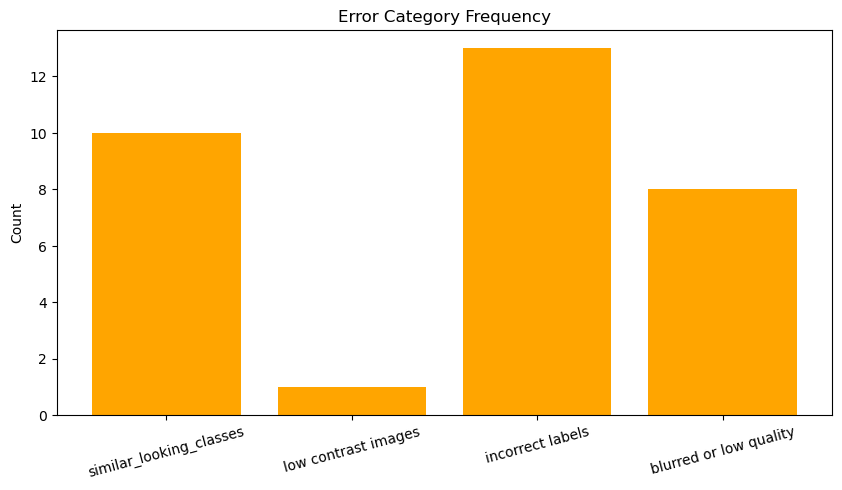

In [51]:
plt.figure(figsize=(10, 5))
plt.bar(error_categories.keys(), error_categories.values(), color='orange')
plt.title("Error Category Frequency")
plt.ylabel("Count")
plt.xticks(rotation=15)
plt.show()

[Carefully examine the misclassified images and describe the possible errors that could be the cause of the misclassifications here]

### C: Categorize Errors

[Group the misclassified images based on the type of errors and calculate the percentage of errors in each category (quantitative analysis)]

In [52]:
total_errors = sum(error_categories.values())

print("Error Category Percentages:\n")
for category, count in error_categories.items():
    percentage = (count / total_errors) * 100
    print(f"{category}: {count} errors ({percentage:.1f}%)")


Error Category Percentages:

similar_looking_classes: 10 errors (31.2%)
low contrast images: 1 errors (3.1%)
incorrect labels: 13 errors (40.6%)
blurred or low quality: 8 errors (25.0%)


### D: Propose Improvements

[Based on the quantitative analysis of the errors, formulate hypotheses about why these errors occurred. Then, suggest and discuss potential improvements for the model and/or dataset]


Based on the error analysis, I think most of the mistakes happened because some images were labeled incorrectly, which confused the model during training. A lot of errors also came from skin types that look very similar, like normal and dry, making it hard for the model to tell them apart. Some images were blurry or had low quality, which probably made it harder for the model to recognize important details. There were also a few images with very low contrast, so the skin features weren't clear enough. To improve the model, I would suggest double-checking the labels, collecting more high-quality images, especially for confusing classes, and using preprocessing techniques like contrast enhancement to help the model learn better.